## 0. Обозначения и параметры

**Толщины слоёв:**  
$t_c$ - толщина коры  
$t_m$ - толщина литосферной мантии  
$a = t_c + t_m$ - общая толщина литосферы  

**Теплопроводности и диффузивности:**  
$k_c, k_m$ - теплопроводность коры и мантии  
$\rho_c, c_{p,c}, \rho_m, c_{p,m}$ - плотность и теплоёмкость  
$\kappa_c = \frac{k_c}{\rho_c c_{p,c}}$  
$\kappa_m = \frac{k_m}{\rho_m c_{p,m}}$

**Эффективная диффузивность и характерное время:**  
$\kappa_{\text{eff}} = \frac{\kappa_c t_c + \kappa_m t_m}{t_c + t_m}$  
$\tau = \frac{a^2}{\pi^2 \kappa_{\text{eff}}}$  
$\tau_n = \frac{\tau}{n^2}$

**Граничные температуры:**  
$T_s$ - температура поверхности  
$T_m$ - температура на LAB

**Коэффициент растяжения и длительность рифтинга:**  
$\beta = \beta_{\text{final}}$  
$T_{\text{rift}}$ - длительность рифтинга

**Спектр МакКензи:**  
$A_n(\beta) = 2\beta \frac{\sin\left(\frac{n\pi}{\beta}\right)}{n\pi}$

---

## 1. До рифтинга

### 1.1. Дорифтовый тепловой поток (q₀)
$q_0 = \frac{T_m - T_s}{\frac{t_c}{k_c} + \frac{t_m}{k_m}} \quad (1)$

До начала растяжения ($t \le 0$):  
$q(t) = q_0, \quad t \le 0 \quad (2)$

---

## 2. Во время рифтинга

Время отсчитываем от **начала рифтинга**:  
$t = 0$ - начало рифтинга  
$t = T_{\text{rift}}$ - конец рифтинга

Безразмерный тепловой поток:  
$\hat{q}(t) = \frac{q(t)}{q_0}$

При $0 < t < T_{\text{rift}}$:  
$\hat{q}(t) = 1 + \sum_{n=1}^{\infty} A_n(\beta) \frac{\tau_n}{T_{\text{rift}}} \left[1 - \exp\left(-\frac{t}{\tau_n}\right)\right] \quad (3)$

где  
$A_n(\beta) = 2\beta \frac{\sin\left(\frac{n\pi}{\beta}\right)}{n\pi}$  
$\tau_n = \frac{\tau}{n^2}, \quad \tau = \frac{a^2}{\pi^2 \kappa_{\text{eff}}} \quad (4)$

Полный тепловой поток:  
$q(t) = q_0 \cdot \hat{q}(t) \quad (5)$

---

## 3. После рифтинга

После окончания рифтинга ($t \ge T_{\text{rift}}$):  
$\hat{q}(t) = 1 + \sum_{n=1}^{\infty} A_n(\beta) \frac{\tau_n}{T_{\text{rift}}} \left[\exp\left(-\frac{t - T_{\text{rift}}}{\tau_n}\right) - \exp\left(-\frac{t}{\tau_n}\right)\right] \quad (6)$

$q(t) = q_0 \cdot \hat{q}(t) \quad (7)$

---

## 4. Связь времени (t) с возрастом (Age)

Для сопоставления с PetroMod:  
$Age_{\text{start}}$ - возраст начала рифтинга (например, 130 Ma)  
$Age_{\text{end}}$ - возраст конца рифтинга (например, 120 Ma)  
$T_{\text{rift}} = Age_{\text{start}} - Age_{\text{end}} \quad (8)$

Для произвольного возраста $Age$:  
$t(Age) = Age_{\text{start}} - Age \quad (9)$

Фазы:  
- если $Age > Age_{\text{start}} \Rightarrow t < 0 \Rightarrow$ **до рифтинга**, используем (2)  
- если $Age_{\text{end}} < Age \le Age_{\text{start}} \Rightarrow 0 \le t \le T_{\text{rift}} \Rightarrow$ **во время рифтинга**, используем (3)  
- если $Age \le Age_{\text{end}} \Rightarrow t \ge T_{\text{rift}} \Rightarrow$ **после рифтинга**, используем (6)

Полный поток как функция возраста:  
$q(Age) = q(t(Age)) \quad (10)$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

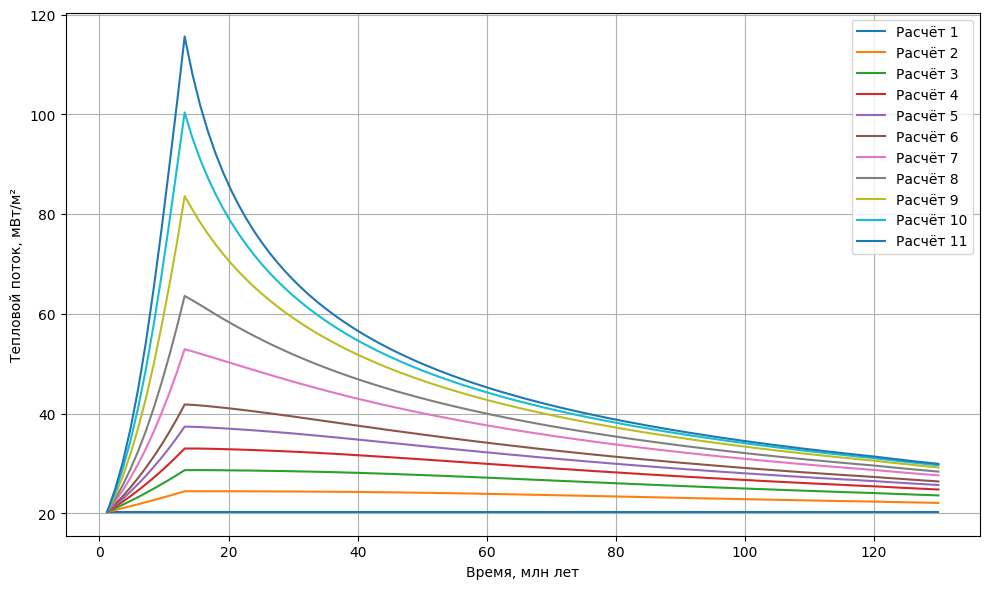

In [16]:
# ЧТЕНИЕ ДАННЫХ ИЗ ФАЙЛА "data.txt <-- твой файл с данными"

MAX_CALC = 22  # всего расчётов в таблице <--- ниже тут не изменять !!!

times = [[] for _ in range(MAX_CALC)]
fluxes = [[] for _ in range(MAX_CALC)]

with open("data.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue  

        if line.startswith("Расчет") or line.startswith("расчет"):
            continue

        line = line.replace(",", ".")
        parts = line.split()

        if len(parts) % 2 != 0:
            print("Странная строка, пропускаю:\n", line)
            continue

        for i in range(0, len(parts), 2):
            col = i // 2          
            if col >= MAX_CALC:
                break
            t = float(parts[i])
            q = float(parts[i + 1])
            times[col].append(t)
            fluxes[col].append(q)

# ---- ВЫБОР, КАКИЕ РАСЧЁТЫ ВИЗУАЛИЗИРОВА ----

# первые 11 расчётов (1..11):
cols_to_plot = list(range(0, 11))

# вторые 11 расчётов (12..22):
# cols_to_plot = list(range(11, 22))

#  конкретные расчёты: 1, 4, 5
# cols_to_plot = [0, 3, 4]   # индексы = номер расчёта - 1

plt.figure(figsize=(10, 6))

for col in cols_to_plot:
    plt.plot(times[col][::-1], fluxes[col], label=f"Расчёт {col+1}")

plt.xlabel("Время, млн лет")
plt.ylabel("Тепловой поток, мВт/м²")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Дорифтовый поток q0 (2 слоя) = 20.960800000000003 mW/m^2
Термодиффузии: κ_c = 6.26590330788804e-07 м²/с, κ_m = 5.295698924731182e-07 м²/с
Эффективная κ_eff = 5.528547976688828e-07 м²/с  →  τ ≈ 90.74134887614228 Myr
q0, который используется в теории = 20.960800000000003 mW/m^2


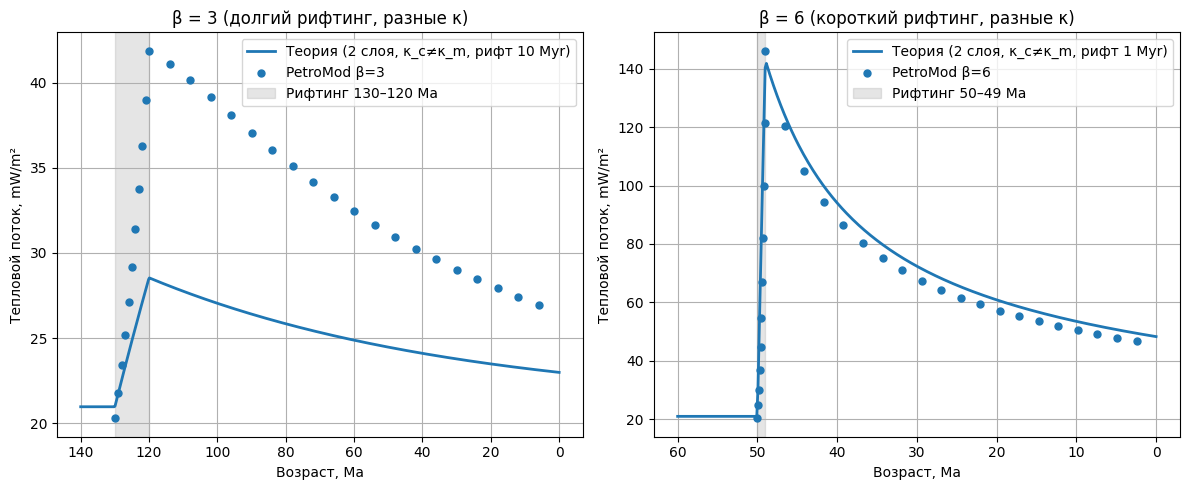

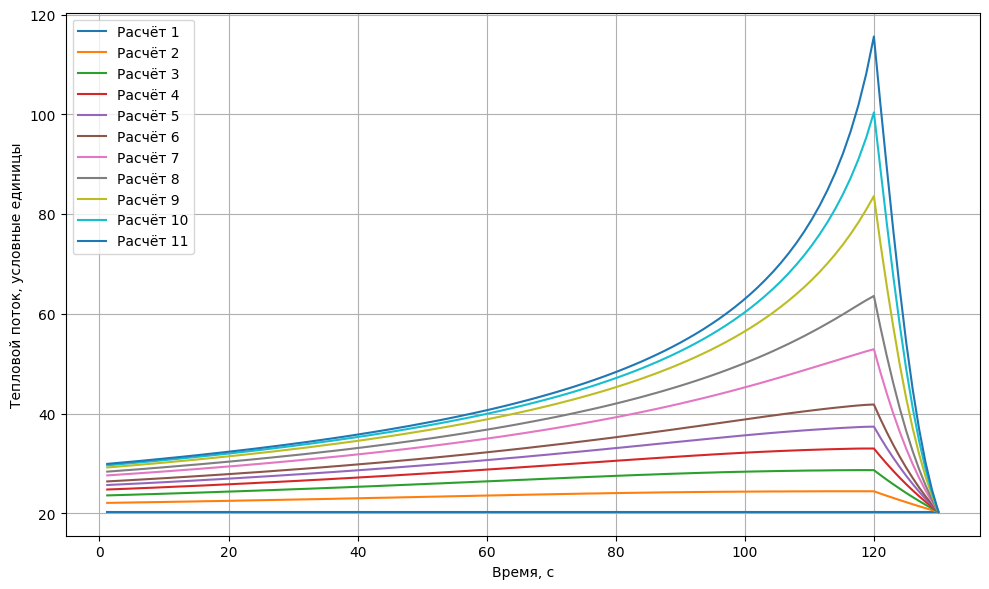

In [148]:
import matplotlib.pyplot as plt

MAX_CALC = 22  # всего расчётов в таблице

# списки для данных: на каждый расчёт – свой список времени и теплового потока
times = [[] for _ in range(MAX_CALC)]
fluxes = [[] for _ in range(MAX_CALC)]

with open("data.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue  # пустые строки пропускаем

        # если вдруг оставите строку с "Расчет 1  Расчет 2 ..." – просто пропустим её
        if line.startswith("Расчет") or line.startswith("расчет"):
            continue

        # заменяем запятую на точку, чтобы float() понял числа
        line = line.replace(",", ".")
        parts = line.split()

        # в строке должны быть пары чисел: (t1, q1, t2, q2, ..., t22, q22)
        if len(parts) % 2 != 0:
            print("Странная строка, пропускаю:\n", line)
            continue

        for i in range(0, len(parts), 2):
            col = i // 2           # номер расчёта (0..21)
            if col >= MAX_CALC:
                break
            t = float(parts[i])
            q = float(parts[i + 1])
            times[col].append(t)
            fluxes[col].append(q)

# ---- ВЫБОР, КАКИЕ РАСЧЁТЫ ВИЗУАЛИЗИРОВА ----

# первые 11 расчётов (1..11):
cols_to_plot = list(range(0, 11))

# вторые 11 расчётов (12..22):
# cols_to_plot = list(range(11, 22))

#  конкретные расчёты: 1, 4, 5
# cols_to_plot = [0, 3, 4]   # индексы = номер расчёта - 1

# Построение графиков
plt.figure(figsize=(10, 6))

for col in cols_to_plot:
    plt.plot(times[col], fluxes[col], label=f"Расчёт {col+1}")

plt.xlabel("Время, с")
plt.ylabel("Тепловой поток, условные единицы")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Дорифтовый поток q0 (2 слоя) = 20.290480000000002 mW/m^2
Термодиффузии: κ_c = 6.065521628498728e-07 м²/с, κ_m = 5.126344086021506e-07 м²/с
Эффективная κ_eff = 5.35174669621604e-07 м²/с  →  τ ≈ 93.7390966366021 Myr


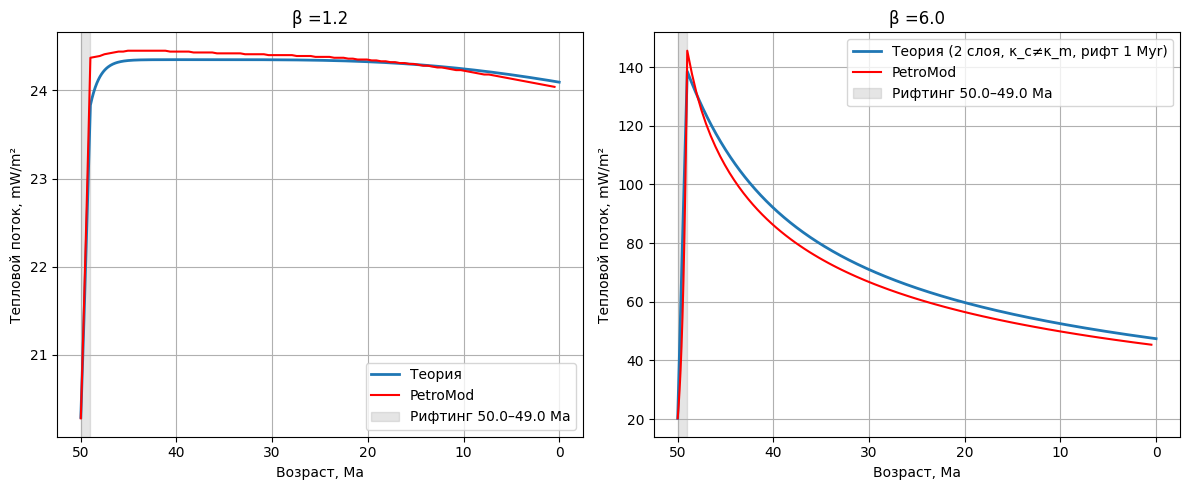

In [13]:
# Расчёт теплового потока при рифтинге по теории МакКензи

# ============================================================
# 0. ПАРАМЕТРЫ: ТЕПЛОПРОВОДНОСТЬ И ДИФФУЗИВНОСТЬ КОРЫ И МАНТИИ

# --- толщина слоёв ---
t_crust_km  = 30.0   # толщина коры, км
t_mantle_km = 95.0   # толщина литосферной мантии, км

# --- теплопроводности (явно задаём для коры и мантии) ---
k_crust  = 1.907      # W/m/K
k_mantle = 1.907       # W/m/K

# --- плотность и теплоёмкость (можно менять отдельно) ---
rho_crust,  cp_crust  = 2620.0, 1200.0   # кг/м3, Дж/кг/К
rho_mantle, cp_mantle = 3100.0, 1200.0

# --- температуры ---
T_surf = 0.0         # °C
T_m    = 1330.0      # температура на LAB, °C

# Перевод в метры
t_crust_m  = t_crust_km  * 1e3
t_mantle_m = t_mantle_km * 1e3
a_m        = t_crust_m + t_mantle_m   # общая толщина литосферы, м

# ============================================================
# 1. ДОРИФТОВЫЙ ПОТОК ДЛЯ ДВУХСЛОЙНОЙ ЛИТОСФЕРЫ

# q0 = (T_m - T_surf) / (t_c/k_c + t_m/k_m)
q0_two_layer = (T_m - T_surf) / (t_crust_m / k_crust + t_mantle_m / k_mantle)  # W/m2
q0_two_layer_mW = q0_two_layer * 1e3  # mW/m2

print("Дорифтовый поток q0 (2 слоя) =", q0_two_layer_mW, "mW/m^2")

# ============================================================
# 2. РАЗНЫЕ ДИФФУЗИВНОСТИ КОРЫ И МАНТИИ → ЭФФЕКТИВНАЯ κ_eff

# Термодиффузии слоёв
kappa_crust  = k_crust  / (rho_crust  * cp_crust)   # м^2/с
kappa_mantle = k_mantle / (rho_mantle * cp_mantle) # м^2/с

# Эффективная диффузивность для всей литосферы
# (толщинно-взвешенное среднее: κ_eff ≈ (κ_c * t_c + κ_m * t_m) / (t_c + t_m))
kappa_eff = (kappa_crust * t_crust_m + kappa_mantle * t_mantle_m) / a_m

# Масштабное тепловое время τ для "эквивалентного однородного слоя"
tau_sec = a_m**2 / (np.pi**2 * kappa_eff)
sec_per_myr = 1e6 * 365.25 * 24 * 3600
tau_myr = tau_sec / sec_per_myr

print("Термодиффузии: κ_c =", kappa_crust, "м²/с, κ_m =", kappa_mantle, "м²/с")
print("Эффективная κ_eff =", kappa_eff, "м²/с  →  τ ≈", tau_myr, "Myr")

# ============================================================
# 3. МАККЕНЗИ С КОНЕЧНЫМ ВРЕМЕНЕМ РИФТИНГА (β(t) ЛИНЕЙНО)

def mckenzie_q_over_q0_finite_t(t, beta_final, T_rift, tau_myr, n_terms=200): # <-- n_terms=200 -- задает по умолчание, ниже можно менять
    """
    МакКензи с растянутым во времени рифтингом.
    t        : время с начала рифта, Myr (0 → начало, T_rift → конец).
    beta_final : конечное β.
    T_rift   : длительность рифтинга, Myr.
    tau_myr  : τ для эквивалентной литосферы (на базе κ_eff).
    n_terms  : число гармоник.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    # спектр МакКензи
    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta_final * np.sin(n * np.pi / beta_final) / (n * np.pi)
    tau_n = tau_myr / (n ** 2)

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age(age_array, age_start_rift, age_end_rift,
                          beta_final, tau_myr, q0, n_terms=200):
    """
    То же самое, но в шкале возрастов (Ma).
    age_array      : массив возрастов.
    age_start_rift : возраст начала рифта.
    age_end_rift   : возраст конца рифта.
    beta_final     : конечное β.
    tau_myr        : τ (из κ_eff).
    q0             : дорифтовый поток (mW/m² или W/m² — консистентно).
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift   # длительность рифтинга > 0

    # время с начала рифта: t = 0 при age = age_start_rift
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t(
            t_from_start[mask], beta_final, T_rift, tau_myr, n_terms=n_terms
        )

    return q0 * q_over_q0

# ============================================================
# 4. ДАННЫЕ PETROMOD (ВЫБИРАЮ ИЗ ФАЙЛА data.txt)

# --- кейс 1: рифтинг 130–120 Ma ---
ages1: list[float] = []
q1_mW: list[float] = []

cols_to_plot = [12]#<-- расчет - 1
for col in cols_to_plot:
    ages1 = times[col] 
    q1_mW = fluxes[col]

age_start1 = 50.0
age_end1   = 49.0
beta1      = 1.2

# --- кейс 2: β = 3, рифтинг 130–120 Ma ---
ages2: list[float] = []
q2_mW: list[float] = []

cols_to_plot = [21] #<-- расчет - 1
for col in cols_to_plot:
    ages2 = times[col] 
    q2_mW = fluxes[col]

age_start2 = 50.0
age_end2   = 49.0
beta2      = 6.0


q0_theor_mW = q0_two_layer_mW

# ============================================================
# 6. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ

age_grid1 = np.linspace(50, 0, 600)  #<-- изменение по оси x!
age_grid2 = np.linspace(50, 0, 600)  #<-- изменение по оси x!

q1_theor_mW = mckenzie_q_finite_age(
    age_grid1, age_start1, age_end1, beta1, tau_myr, q0_theor_mW, n_terms=9 # <-- тут задается параметры для расчета
)

q2_theor_mW = mckenzie_q_finite_age(
    age_grid2, age_start2, age_end2, beta2, tau_myr, q0_theor_mW, n_terms=6
)

# ============================================================
# 7. ГРАФИКИ

plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# --- кейс 1 ---
ax = axes[0]
ax.plot(age_grid1, q1_theor_mW, label='Теория', lw=2)
ax.plot(ages1, q1_mW, label='PetroMod', color='red')
ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label=f'Рифтинг {age_start1}–{age_end1} Ma')



ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β ={beta1}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# --- кейс 2---
ax = axes[1]
ax.plot(age_grid2, q2_theor_mW, label='Теория (2 слоя, κ_c≠κ_m, рифт 1 Myr)', lw=2)
ax.plot(ages2, q2_mW, label='PetroMod', color='red')
ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label=f'Рифтинг {age_start2}–{age_end2} Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β ={beta2}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("comparison_petromod_theory_T50-49_1.2 vs 6.png", dpi=300)
plt.show()

### Изменение формулы МакКензи: один β против двух β

В классическом варианте МакКензи для однородной литосферы используется **один** коэффициент растяжения $\beta$ для всей литосферы.
Спектр МакКензи задаётся как

$$
A_n(\beta) = 2 \beta \frac{\sin\left(\dfrac{n\pi}{\beta}\right)}{n\pi}.
$$

Тогда безразмерный тепловой поток во время рифтинга ($0 < t < T_{\text{rift}}$):

$$
\hat{q}(t) = 1 + \sum_{n=1}^{\infty} A_n(\beta) \frac{\tau_n}{T_{\text{rift}}} \left[ 1 - \exp\left(-\frac{t}{\tau_n}\right) \right].
$$

А после рифтинга ($t \ge T_{\text{rift}}$):

$$
\hat{q}(t) = 1 + \sum_{n=1}^{\infty} A_n(\beta) \frac{\tau_n}{T_{\text{rift}}} \left[ \exp\left(-\frac{t - T_{\text{rift}}}{\tau_n}\right) - \exp\left(-\frac{t}{\tau_n}\right) \right].
$$

---

В новой постановке мы допускаем, что кора и мантия растягиваются по-разному:

$$
\beta_c \neq \beta_m.
$$

Для них определяем отдельные спектры:

$$
A_n^{(c)} = 2 \beta_c \frac{\sin\left(\dfrac{n\pi}{\beta_c}\right)}{n\pi}, \qquad A_n^{(m)} = 2 \beta_m \frac{\sin\left(\dfrac{n\pi}{\beta_m}\right)}{n\pi}.
$$

Затем строим **эффективный спектр** как взвешенную сумму спектров коры и мантии:

$$
A_n^{\text{eff}} = w_c A_n^{(c)} + w_m A_n^{(m)},
$$

где, например, веса берутся по толщине:

$$
w_c = \frac{t_c}{t_c + t_m}, \qquad w_m = \frac{t_m}{t_c + t_m}.
$$

После этого во всех формулах для $\hat{q}(t)$ мы просто заменяем $A_n(\beta)$ на $A_n^{\text{eff}}$.

Во время рифтинга:

$$
\hat{q}(t) = 1 + \sum_{n=1}^{\infty} A_n^{\text{eff}} \frac{\tau_n}{T_{\text{rift}}} \left[ 1 - \exp\left(-\frac{t}{\tau_n}\right) \right],
$$

и после рифтинга:

$$
\hat{q}(t) = 1 + \sum_{n=1}^{\infty} A_n^{\text{eff}} \frac{\tau_n}{T_{\text{rift}}} \left[ \exp\left(-\frac{t - T_{\text{rift}}}{\tau_n}\right) - \exp\left(-\frac{t}{\tau_n}\right) \right].
$$

Размерный поток, как и раньше, получается масштабированием на дорифтовый поток $q_0$:

$$
q(t) = q_0 \hat{q}(t).

Дорифтовый поток q0 (2 слоя) = 20.45008 mW/m^2
Термодиффузии: κ_c = 6.11323155216285e-07 м²/с, κ_m = 5.166666666666667e-07 м²/с
Эффективная κ_eff = 5.393842239185751e-07 м²/с  →  τ ≈ 93.00752200104071 Myr
----------Теоретические расчеты----------
Кейс 1: β_коры = 1.2 , β_мантии = 1.2
Индекс :   Возраст   Поток (mW/m²)
  0:  50.00  20.45
100:  41.65  24.55
200:  33.31  24.54
300:  24.96  24.53
400:  16.61  24.49
500:  8.26  24.41
----------Теоретические расчеты----------
Кейс 2: β_коры = 6.0 , β_мантии = 6.0
Индекс :   Возраст   Поток (mW/m²)
  0:  50.00  20.45
100:  41.65  98.01
200:  33.31  76.70
300:  24.96  64.90
400:  16.61  57.24
500:  8.26  51.76


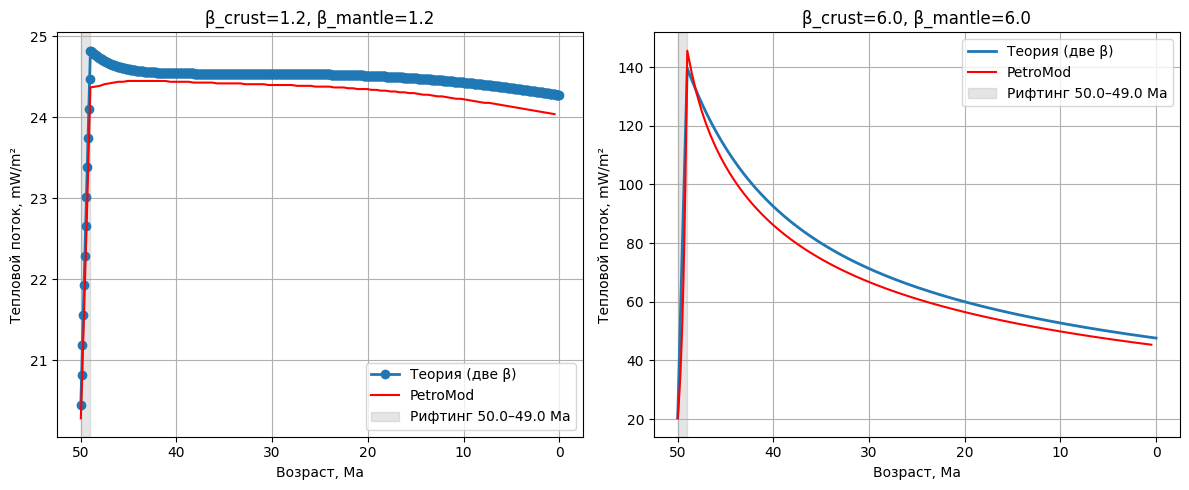

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Расчёт теплового потока при рифтинге по теории МакКензи
# с возможностью задать разные β для коры и мантии
# ============================================================

# 0. ПАРАМЕТРЫ: ТЕПЛОПРОВОДНОСТЬ И ДИФФУЗИВНОСТЬ КОРЫ И МАНТИИ

# --- толщина слоёв ---
t_crust_km  = 30.0   # толщина коры, км
t_mantle_km = 95.0   # толщина литосферной мантии, км

# --- теплопроводности (явно задаём для коры и мантии) ---
k_crust  = 1.907      # W/m/K
k_mantle = 1.907      # W/m/K

k_crust  = 1.922      # W/m/K
k_mantle = 1.922      # W/m/K

# 1.922

# --- плотность и теплоёмкость (можно менять отдельно) ---
rho_crust,  cp_crust  = 2620.0, 1200.0   # кг/м3, Дж/кг/К
rho_mantle, cp_mantle = 3100.0, 1200.0

# --- температуры ---
T_surf = 0.0         # °C
T_m    = 1330.0      # температура на LAB, °C

# Перевод в метры
t_crust_m  = t_crust_km  * 1e3
t_mantle_m = t_mantle_km * 1e3
a_m        = t_crust_m + t_mantle_m   # общая толщина литосферы, м

# ============================================================
# 1. ДОРИФТОВЫЙ ПОТОК ДЛЯ ДВУХСЛОЙНОЙ ЛИТОСФЕРЫ

# q0 = (T_m - T_surf) / (t_c/k_c + t_m/k_m)
q0_two_layer = (T_m - T_surf) / (t_crust_m / k_crust + t_mantle_m / k_mantle)  # W/m2
q0_two_layer_mW = q0_two_layer * 1e3  # mW/m2

print("Дорифтовый поток q0 (2 слоя) =", q0_two_layer_mW, "mW/m^2")

# ============================================================
# 2. РАЗНЫЕ ДИФФУЗИВНОСТИ КОРЫ И МАНТИИ → ЭФФЕКТИВНАЯ κ_eff

# Термодиффузии слоёв
kappa_crust  = k_crust  / (rho_crust  * cp_crust)   # м^2/с
kappa_mantle = k_mantle / (rho_mantle * cp_mantle) # м^2/с

# Эффективная диффузивность для всей литосферы
# κ_eff ≈ (κ_c * t_c + κ_m * t_m) / (t_c + t_m)
kappa_eff = (kappa_crust * t_crust_m + kappa_mantle * t_mantle_m) / a_m

# Масштабное тепловое время τ для "эквивалентного однородного слоя"
tau_sec = a_m**2 / (np.pi**2 * kappa_eff)
sec_per_myr = 1e6 * 365.25 * 24 * 3600
tau_myr = tau_sec / sec_per_myr

print("Термодиффузии: κ_c =", kappa_crust, "м²/с, κ_m =", kappa_mantle, "м²/с")
print("Эффективная κ_eff =", kappa_eff, "м²/с  →  τ ≈", tau_myr, "Myr")

# ============================================================
# 3. МАККЕНЗИ: ОДИН β (ТВОЯ ИСХОДНАЯ ВЕРСИЯ, ОСТАВЛЯЕМ ДЛЯ СРАВНЕНИЯ)
# ============================================================

def mckenzie_q_over_q0_finite_t_single_beta(t, beta_final, T_rift, tau_myr, n_terms=200):
    """
    Классический МакКензи с одним β для всей литосферы.
    t        : время с начала рифта, Myr (0 → начало, T_rift → конец).
    beta_final : конечное β.
    T_rift   : длительность рифтинга, Myr.
    tau_myr  : τ для эквивалентной литосферы (на базе κ_eff).
    n_terms  : число гармоник.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    # спектр МакКензи
    n = np.arange(1, n_terms + 1, dtype=float)
    A_n = 2.0 * beta_final * np.sin(n * np.pi / beta_final) / (n * np.pi)
    tau_n = tau_myr / (n ** 2)

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age_single_beta(age_array, age_start_rift, age_end_rift,
                                      beta_final, tau_myr, q0, n_terms=200):
    """
    Вариант с одним β в шкале возрастов (Ma).
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift   # длительность рифтинга > 0

    # время с начала рифта: t = 0 при age = age_start_rift
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t_single_beta(
            t_from_start[mask], beta_final, T_rift, tau_myr, n_terms=n_terms
        )

    return q0 * q_over_q0

# ============================================================
# 3*. МАККЕНЗИ: РАЗНЫЕ β ДЛЯ КОРЫ И МАНТИИ (НОВАЯ ВЕРСИЯ)
# ============================================================

def mckenzie_q_over_q0_finite_t_two_beta(t, beta_crust, beta_mantle,
                                         T_rift, tau_myr,
                                         t_crust_m, t_mantle_m,
                                         n_terms=200):
    """
    МакКензи с растянутым во времени рифтингом
    и разными β для коры и мантии (аппроксимация).

    t          : время с начала рифта, Myr (0 → начало, T_rift → конец).
    beta_crust : β для коры.
    beta_mantle: β для мантии.
    T_rift     : длительность рифтинга, Myr.
    tau_myr    : τ для эквивалентной литосферы.
    t_crust_m, t_mantle_m : толщины в метрах (для весов w_c, w_m).
    n_terms    : число гармоник.
    """
    t = np.atleast_1d(t).astype(float)
    q_over_q0 = np.ones_like(t)

    n = np.arange(1, n_terms + 1, dtype=float)

    # спектры для коры и мантии
    A_n_crust  = 2.0 * beta_crust  * np.sin(n * np.pi / beta_crust)  / (n * np.pi)
    A_n_mantle = 2.0 * beta_mantle * np.sin(n * np.pi / beta_mantle) / (n * np.pi)

    # веса по толщине (можно поменять на веса по тепловому содержанию, если нужно)
    a_m = t_crust_m + t_mantle_m
    w_crust  = t_crust_m  / a_m
    w_mantle = t_mantle_m / a_m

    A_n_eff = w_crust * A_n_crust + w_mantle * A_n_mantle

    tau_n = tau_myr / (n ** 2)

    for i, ti in enumerate(t):
        if ti <= 0.0:
            # до начала рифта: q = q0
            continue
        elif ti < T_rift:
            # во время рифтинга
            contrib = A_n_eff * (tau_n / T_rift) * (1.0 - np.exp(-ti / tau_n))
        else:
            # после рифтинга
            contrib = A_n_eff * (tau_n / T_rift) * (
                np.exp(-(ti - T_rift) / tau_n) - np.exp(-ti / tau_n)
            )
        q_over_q0[i] += np.sum(contrib)

    return q_over_q0 if t.size > 1 else float(q_over_q0[0])


def mckenzie_q_finite_age_two_beta(age_array,
                                   age_start_rift, age_end_rift,
                                   beta_crust, beta_mantle,
                                   tau_myr, q0,
                                   t_crust_m, t_mantle_m,
                                   n_terms=200):
    """
    То же самое, но в шкале возрастов (Ma),
    с разными β для коры и мантии.
    """
    age_array = np.asarray(age_array, dtype=float)
    T_rift = age_start_rift - age_end_rift   # длительность рифтинга > 0

    # время с начала рифта: t = 0 при age = age_start_rift
    t_from_start = age_start_rift - age_array  # Myr

    q_over_q0 = np.ones_like(age_array)
    mask = t_from_start > 0.0
    if np.any(mask):
        q_over_q0[mask] = mckenzie_q_over_q0_finite_t_two_beta(
            t_from_start[mask],
            beta_crust, beta_mantle,
            T_rift, tau_myr,
            t_crust_m, t_mantle_m,
            n_terms=n_terms
        )

    return q0 * q_over_q0

# ============================================================
# 4. ДАННЫЕ PETROMOD (ВЫБИРАЮ ИЗ ФАЙЛА data.txt)
# (предполагаю, что times и fluxes уже заполнены где-то выше в коде)
# ============================================================

# --- кейс 1 ---
ages1: list[float] = []
q1_mW: list[float] = []

cols_to_plot = [12]  # <-- расчёт №13 (индексация с 0)
for col in cols_to_plot:
    ages1 = times[col]
    q1_mW = fluxes[col]

age_start1 = 50.0
age_end1   = 49.0

# теперь задаём отдельно β для коры и мантии
beta1_crust  = 1.2
beta1_mantle = 1.2  # можешь сделать, например, 1.4 и смотреть эффект

# --- кейс 2 ---
ages2: list[float] = []
q2_mW: list[float] = []

cols_to_plot = [21]  # <-- расчёт №22
for col in cols_to_plot:
    ages2 = times[col]
    q2_mW = fluxes[col]

age_start2 = 50.0
age_end2   = 49.0

beta2_crust  = 6.0
beta2_mantle = 6.0  # и тут можешь задать другое значение

q0_theor_mW = q0_two_layer_mW

# ============================================================
# 6. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ
# ============================================================

# Единный грид для рифтинга и охлаждения
age_grid1 = np.linspace(50, 0, 600)  # изменение по оси x
age_grid2 = np.linspace(50, 0, 600)


# --- ВАРИАНТ С ДВУМЯ β (новая функция) ---
q1_theor_mW = mckenzie_q_finite_age_two_beta(
    age_grid1, age_start1, age_end1,
    beta1_crust, beta1_mantle,
    tau_myr, q0_theor_mW,
    t_crust_m, t_mantle_m,
    n_terms=5  # число гармоник
)

q2_theor_mW = mckenzie_q_finite_age_two_beta(
    age_grid2, age_start2, age_end2,
    beta2_crust, beta2_mantle,
    tau_myr, q0_theor_mW,
    t_crust_m, t_mantle_m,
    n_terms=5
)

print(10*"-" + "Теоретические расчеты" + 10*"-")
print("Кейс 1: β_коры =", beta1_crust, ", β_мантии =", beta1_mantle)
print("Индекс :   Возраст   Поток (mW/m²)")
for i in range(0, len(age_grid1), 100):
    age = age_grid1[i]
    q   = q1_theor_mW[i]
    print(f"{i:3d}:  {age:.2f}  {q:.2f}")


print(10*"-" + "Теоретические расчеты" + 10*"-")
print("Кейс 2: β_коры =", beta2_crust, ", β_мантии =", beta2_mantle)
print("Индекс :   Возраст   Поток (mW/m²)")
for i in range(0, len(age_grid2), 100):
    age = age_grid2[i]
    q   = q2_theor_mW[i]
    print(f"{i:3d}:  {age:.2f}  {q:.2f}")

# Если захочешь вернуться к "старому" варианту с одним β — просто используй:
# q1_theor_mW = mckenzie_q_finite_age_single_beta(...)
# q2_theor_mW = mckenzie_q_finite_age_single_beta(...)

# ============================================================
# 7. ГРАФИКИ
# ============================================================

plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# --- кейс 1 ---
ax = axes[0]
ax.plot(age_grid1, q1_theor_mW, label='Теория (две β)', lw=2, marker='o')
ax.plot(ages1, q1_mW, label='PetroMod', color='red')
ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label=f'Рифтинг {age_start1}–{age_end1} Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β_crust={beta1_crust}, β_mantle={beta1_mantle}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# --- кейс 2 ---
ax = axes[1]
ax.plot(age_grid2, q2_theor_mW, label='Теория (две β)', lw=2)
ax.plot(ages2, q2_mW, label='PetroMod', color='red')
ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label=f'Рифтинг {age_start2}–{age_end2} Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β_crust={beta2_crust}, β_mantle={beta2_mantle}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("comparison_petromod_theory_T50-49_two_beta.png", dpi=300)
plt.show()


### Разные грид на фазы растяжения и охлажения

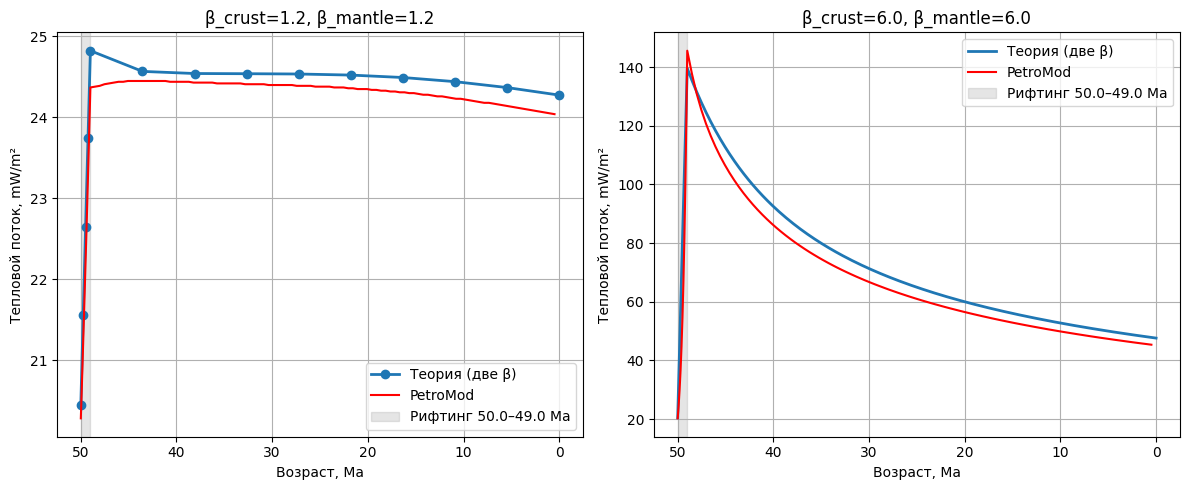

In [50]:
# ============================================================
# 6. ТЕОРЕТИЧЕСКИЕ КРИВЫЕ: ОТДЕЛЬНО РИФТИНГ И ОХЛАЖДЕНИЕ
# ============================================================

# --- общие параметры рифтинга ---
T_rift1 = age_start1 - age_end1   # 1 Myr
T_rift2 = age_start2 - age_end2   # 1 Myr

# --- единый (старый) грид, если всё ещё нужен ---
age_grid1 = np.linspace(age_start1, 0, 600)
age_grid2 = np.linspace(age_start2, 0, 600)

# --- НОВОЕ: отдельные сетки ---

# кейс 1
age1_rifting  = np.linspace(age_start1, age_end1, 5)   # 50 → 49 Ma
age1_cooling  = np.linspace(age_end1,   0.0,      10)   # 49 → 0 Ma

# кейс 2
age2_rifting  = np.linspace(age_start2, age_end2, 100)
age2_cooling  = np.linspace(age_end2,   0.0,      200)

# теоретические кривые на этих сетках
q1_rifting_mW = mckenzie_q_finite_age_two_beta(
    age1_rifting, age_start1, age_end1,
    beta1_crust, beta1_mantle,
    tau_myr, q0_theor_mW,
    t_crust_m, t_mantle_m,
    n_terms=5
)

q1_cooling_mW = mckenzie_q_finite_age_two_beta(
    age1_cooling, age_start1, age_end1,
    beta1_crust, beta1_mantle,
    tau_myr, q0_theor_mW,
    t_crust_m, t_mantle_m,
    n_terms=5
)

q2_rifting_mW = mckenzie_q_finite_age_two_beta(
    age2_rifting, age_start2, age_end2,
    beta2_crust, beta2_mantle,
    tau_myr, q0_theor_mW,
    t_crust_m, t_mantle_m,
    n_terms=5
)

q2_cooling_mW = mckenzie_q_finite_age_two_beta(
    age2_cooling, age_start2, age_end2,
    beta2_crust, beta2_mantle,
    tau_myr, q0_theor_mW,
    t_crust_m, t_mantle_m,
    n_terms=5
)

# если нужен непрерывный массив (рифинг+охлаждение) без дублирования точки 49 Ma:
age1_full = np.concatenate([age1_rifting, age1_cooling[1:]])
q1_full   = np.concatenate([q1_rifting_mW, q1_cooling_mW[1:]])

age2_full = np.concatenate([age2_rifting, age2_cooling[1:]])
q2_full   = np.concatenate([q2_rifting_mW, q2_cooling_mW[1:]])


# ============================================================
# 7. ГРАФИКИ
# ============================================================

plt.rcParams['figure.figsize'] = (12, 5)
fig, axes = plt.subplots(1, 2)

# --- кейс 1 ---
ax = axes[0]
ax.plot(age1_full, q1_full, label='Теория (две β)', lw=2, marker='o')
ax.plot(ages1, q1_mW, label='PetroMod', color='red')
ax.axvspan(age_start1, age_end1, color='grey', alpha=0.2,
           label=f'Рифтинг {age_start1}–{age_end1} Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β_crust={beta1_crust}, β_mantle={beta1_mantle}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

# --- кейс 2 ---
ax = axes[1]
ax.plot(age2_full, q2_full, label='Теория (две β)', lw=2)
ax.plot(ages2, q2_mW, label='PetroMod', color='red')
ax.axvspan(age_start2, age_end2, color='grey', alpha=0.2,
           label=f'Рифтинг {age_start2}–{age_end2} Ma')

ax.set_xlabel('Возраст, Ma')
ax.set_ylabel('Тепловой поток, mW/m²')
ax.set_title(f"β_crust={beta2_crust}, β_mantle={beta2_mantle}")
ax.invert_xaxis()
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("comparison_petromod_theory_T50-49_two_beta.png", dpi=300)
plt.show()



## Сравнение: βэфф VS βкора/мантия

----------Сравнение расчетов----------
Кейс эффективный бета: β_эфф = 2.1
Кейс два бета: β_коры = 1.2 , β_мантии = 3
Индекс :   Возраст   β_эфф (mW/m²)   β_коры/мантии(mW/m²)   Разница
  0:  130.00  20.45, 20.45, diff = 0.00
100:  108.30  42.36, 48.75, diff = 6.39
200:  86.59  38.67, 40.90, diff = 2.23
300:  64.89  34.87, 35.77, diff = 0.90
400:  43.19  31.83, 32.24, diff = 0.41
500:  21.49  29.44, 29.65, diff = 0.21


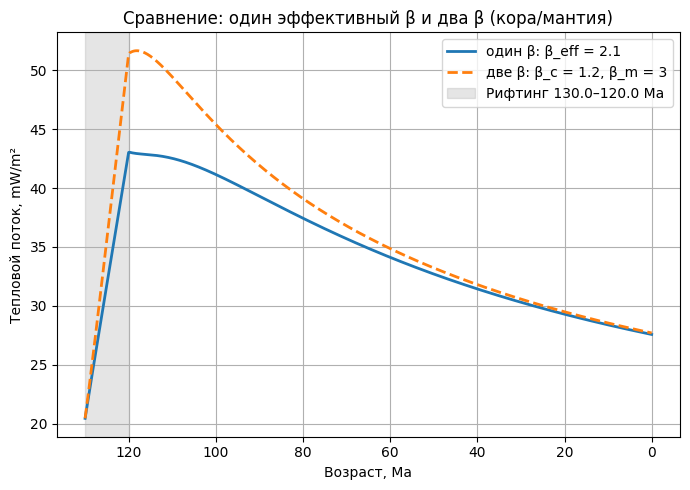

In [51]:
# Сетка возрастов для сравнения
age_grid = np.linspace(130, 0, 600)  # Ma

# --- параметры рифтинга ---
age_start = 130.0   # начало рифтинга, Ma
age_end   = 120.0   # конец рифтинга, Ma

# --- один эффективный β ---
beta_eff = 2.1

q_single_mW = mckenzie_q_finite_age(
    age_grid,
    age_start_rift=age_start,
    age_end_rift=age_end,
    beta_final=beta_eff,
    tau_myr=tau_myr,
    q0=q0_two_layer_mW,
    n_terms=5
)

# --- два разных β для коры и мантии ---
beta_crust  = 1.2
beta_mantle = 3

q_two_mW = mckenzie_q_finite_age_two_beta(
    age_grid,
    age_start_rift=age_start,
    age_end_rift=age_end,
    beta_crust=beta_crust,
    beta_mantle=beta_mantle,
    tau_myr=tau_myr,
    q0=q0_two_layer_mW,
    t_crust_m=t_crust_m,
    t_mantle_m=t_mantle_m,
    n_terms=5
)

print(10*"-" + "Сравнение расчетов" + 10*"-")
print("Кейс эффективный бета: β_эфф =", beta_eff)
print("Кейс два бета: β_коры =", beta_crust, ", β_мантии =", beta_mantle)
print("Индекс :   Возраст   β_эфф (mW/m²)   β_коры/мантии(mW/m²)   Разница")
for i in range(0, len(age_grid), 100):
    age = age_grid[i]
    q1   = q_single_mW[i]
    q2 = q_two_mW[i]
    print(f"{i:3d}:  {age:.2f}  {q1:.2f}, {q2:.2f}, diff = {q2 - q1:.2f}")

# --- визуализация ---
plt.figure(figsize=(7, 5))

plt.plot(age_grid, q_single_mW, label=fr"один β: β_eff = {beta_eff}", lw=2)
plt.plot(age_grid, q_two_mW, label=fr"две β: β_c = {beta_crust}, β_m = {beta_mantle}", lw=2, linestyle="--")

# зона рифтинга
plt.axvspan(age_start, age_end, color="grey", alpha=0.2,
            label=f'Рифтинг {age_start}–{age_end} Ma')

plt.gca().invert_xaxis()
plt.xlabel("Возраст, Ma")
plt.ylabel("Тепловой поток, mW/m²")
plt.title("Сравнение: один эффективный β и два β (кора/мантия)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# вывод табличных данных + расхождение
# по интервалом времени - распределение точек изменить

## Эффективная теплопроводность по глубине (гармоническое среднее)

Рассматриваем одномерный столб литосферы толщиной $a$, глубина $z \in [0, a]$, местная bulk-теплопроводность $\lambda_{\text{bulk}}(z)$.

---

### 1. Теоретический вывод

В стационарной теплопроводности (без внутренних источников):

$$
q = -\lambda_{\text{bulk}}(z)\,\frac{dT}{dz} = \text{const по } z.
$$

Отсюда

$$
\frac{dT}{dz} = -\frac{q}{\lambda_{\text{bulk}}(z)}.
$$

Перепад температуры через столб:

$$
T_m - T_s
= \int_0^a \frac{dT}{dz}\,dz
= - \int_0^a \frac{q}{\lambda_{\text{bulk}}(z)}\,dz
= q \int_0^a \frac{dz}{\lambda_{\text{bulk}}(z)}.
$$

Тепловой поток:

$$
q = \frac{T_m - T_s}
{\displaystyle \int_0^a \frac{dz}{\lambda_{\text{bulk}}(z)}}.
\tag{1}
$$

Введём эффективную теплопроводность по глубине $k_{\text{eff}}$ так, чтобы

$$
q = k_{\text{eff}}\,\frac{T_m - T_s}{a}.
$$

Сравнивая с (1), получаем:

$$
k_{\text{eff}} =
\frac{a}
{\displaystyle \int_0^a \frac{dz}{\lambda_{\text{bulk}}(z)}}.
\tag{2}
$$

Это гармоническое среднее по глубине для $\lambda_{\text{bulk}}(z)$.

---

### 2. Дискретный вариант (слойки по глубине)

Пусть столб разбит на $N$ слоёв:

- слой $i$ толщиной $\Delta z_i$,
- теплопроводность слоя $\lambda_i$ (bulk-значение).

Тогда интеграл заменяем суммой:

$$
\int_0^a \frac{dz}{\lambda_{\text{bulk}}(z)}
\approx
\sum_{i=1}^N \frac{\Delta z_i}{\lambda_i},
\qquad
a = \sum_{i=1}^N \Delta z_i.
$$

Эффективная теплопроводность:

$$
k_{\text{eff}} \approx
\frac{\displaystyle \sum_{i=1}^N \Delta z_i}
{\displaystyle \sum_{i=1}^N \dfrac{\Delta z_i}{\lambda_i}}.
\tag{3}
$$

Если все слои одинаковой толщины $\Delta z_i = a/N$, то:

$$
k_{\text{eff}} \approx
\frac{N}{\displaystyle \sum_{i=1}^N \dfrac{1}{\lambda_i}}.
\tag{4}
$$

---

### 3. Теплопроводность матрицы по Sekiguchi–Waples

Пусть $\lambda_m$ — теплопроводность матрицы при $20^\circ\text{C}$, а $T$ — абсолютная температура (K).

Модель Sekiguchi–Waples:

$$
\lambda_{\text{matrix}}(T) =
358 \,(1.0227\,\lambda_m - 1.882)
\left(\frac{1}{T} - 0.00068\right) + 1.84.
\tag{5}
$$

---

### 4. Bulk-теплопроводность (матрица + флюид + пористость)

Обозначим:

- $\lambda_{\text{mat}}(T)$ — теплопроводность матрицы,
- $\lambda_f$ — теплопроводность флюида,
- $\phi(z)$ — пористость на глубине $z$.

Гармоническое смешение (в направлении теплового потока):

$$
\frac{1}{\lambda_{\text{bulk}}(z)} =
\frac{1 - \phi(z)}{\lambda_{\text{mat}}(T(z))}
+
\frac{\phi(z)}{\lambda_f}.
\tag{6}
$$

---

### 5. Итоговая схема

1. Задаём профили $T(z)$, $\phi(z)$ и $\lambda_f$.

2. Для каждой глубины:
   - считаем $\lambda_{\text{mat}}(T)$ по (5),
   - считаем $\lambda_{\text{bulk}}(z)$ по (6).

3. Считаем $k_{\text{eff}}$ по (3) или (4).

4. Используем $k_{\text{eff}}$ как эффективную теплопроводность коры/мантии в модели МакКензи.


## Расчет теплопроводности: литосфера

k_eff ≈ 1.969 W/m/K


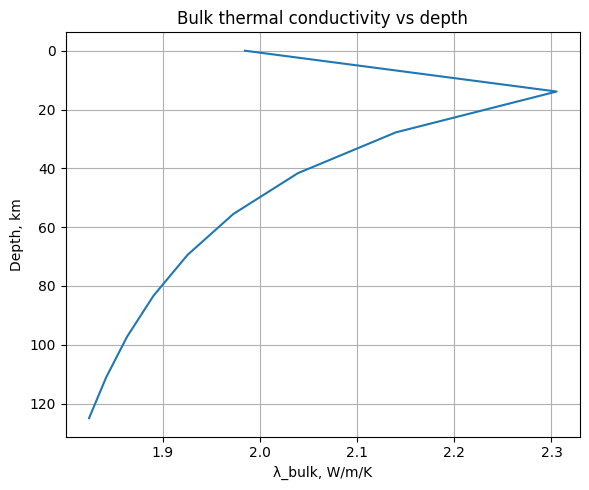

In [ ]:
# ----- ПАРАМЕТРЫ -----
# Матрица при 20°C (как в PetroMod, например 2.6 W/m/K)
lambda_m_20 = 2.6  # W/m/K

# Температура на поверхности
T_surf_C = 0.0      # °C
T_lab_C  = 1330.0   # °C

# Толщина столба 
a_km = 125.0         # км
a_m  = a_km * 1e3

# Параметры пористости (пример: экспонента)
phi0   = 0.1        # пористость у поверхности
z_star = 3e3        # м, масштаб убывания пористости
lambda_fluid = 0.6  # W/m/K (например, вода/флюид)

# Число слоёв
N = 10

# ----- ФУНКЦИИ -----

def Sekiguchi_Waples(T_K, lambda_m, correction=True):
    """
    T_K       : температура в Кельвинах
    lambda_m  : теплопроводность матрицы при 20°C
    """
    if correction:
        return 358.0 * (1.0227 * lambda_m - 1.882) * (T_K**(-1) - 0.00068) + 1.84
    else:
        return lambda_m

def phi_of_z(z):
    """Простейший профиль пористости: phi(z) = phi0 * exp(-z / z_star)."""
    return phi0 * np.exp(-z / z_star)

def T_of_z(z):
    """
    Линейный профили температуры от поверхности до LAB.
    Для иллюстрации: T(z) = T_surf + (T_lab - T_surf) * z / a.
    """
    return T_surf_C + (T_lab_C - T_surf_C) * (z / a_m)

# ----- СЕТКА ПО ГЛУБИНЕ -----

z = np.linspace(0, a_m, N)  # м
dz = z[1] - z[0]

T_C = T_of_z(z)
T_K = T_C + 273.15

phi = phi_of_z(z)

# Теплопроводность матрицы как функция T
lambda_mat = Sekiguchi_Waples(T_K, lambda_m_20, correction=True)

# Bulk-λ по гармоническому смешению матрица+флюид
lambda_bulk = 1.0 / (
    (1.0 - phi) / lambda_mat + phi / lambda_fluid
)

# ----- ЭФФЕКТИВНАЯ ТЕПЛОПРОВОДНОСТЬ k_eff -----

# Формула (4): k_eff ~= N / sum(1/lambda_i) для равных слоёв
k_eff = N / np.sum(1.0 / lambda_bulk)
print(f"k_eff ≈ {k_eff:.3f} W/m/K")

# ----- ВИЗУАЛИЗАЦИЯ -----

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(lambda_bulk, z / 1e3, label="λ_bulk(z)")
ax1.invert_yaxis()
ax1.set_xlabel("λ_bulk, W/m/K")
ax1.set_ylabel("Depth, km")
ax1.grid(True)
ax1.set_title("Bulk thermal conductivity vs depth")

plt.tight_layout()
plt.show()


## Расчет теплопроводности: кора + мантия 

k_c_eff (кора 0–30 км)   ≈ 2.244 W/m/K
k_m_eff (мантия 30–125 км) ≈ 1.922 W/m/K


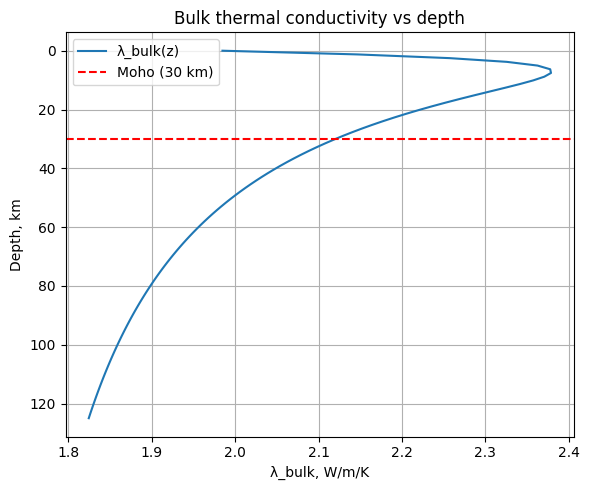

In [ ]:
# Глубины
z_crust_top_km  = 0.0
z_crust_bot_km  = 30.0     # кора: 0–30 км
z_mantle_top_km = 30.0
z_mantle_bot_km = 125.0    # мантия: 30–120 км

z_max_km = z_mantle_bot_km
z_max_m  = z_max_km * 1e3

# Температуры (примерный линейный профиль)
T_surf_C = 0.0
T_lab_C  = 1330.0

# Матрица при 20°C (как в PetroMod, например 2.6 W/m/K)
lambda_m_20 = 2.6  # W/m/K

# Параметры пористости (игрушечный пример)
phi0   = 0.1       # пористость у поверхности
z_star = 3e3       # м, масштаб убывания пористости

# Теплопроводность флюида
lambda_fluid = 0.6 # W/m/K

# Сетка
N = 100
z = np.linspace(0, z_max_m, N)  # м
dz = z[1] - z[0]

# ---------- ФУНКЦИИ ----------
def Sekiguchi_Waples(T_K, lambda_m, correction=True):
    """
    T_K      : температура в Кельвинах
    lambda_m : теплопроводность матрицы при 20°C
    """
    if correction:
        return 358.0 * (1.0227 * lambda_m - 1.882) * (T_K**(-1) - 0.00068) + 1.84
    else:
        return lambda_m

def phi_of_z(z):
    """Простейший профиль пористости: экспоненциальное уменьшение."""
    return phi0 * np.exp(-z / z_star)

def T_of_z(z):
    """
    Линейный профиль температуры от поверхности до LAB.
    T(z) = T_surf + (T_lab - T_surf) * (z / z_max)
    """
    return T_surf_C + (T_lab_C - T_surf_C) * (z / z_max_m)

# ---------- РАСЧЁТ ПРОФИЛЕЙ ----------

T_C = T_of_z(z)
T_K = T_C + 273.15

phi = phi_of_z(z)

# Теплопроводность матрицы λ_matrix(T)
lambda_mat = Sekiguchi_Waples(T_K, lambda_m_20, correction=True)

# Bulk λ(z) по гармоническому смешению матрица+флюид
lambda_bulk = 1.0 / (
    (1.0 - phi) / lambda_mat + phi / lambda_fluid
)

# ---------- ВЫДЕЛЯЕМ КОРУ И МАНТИЮ ----------

z_km = z / 1e3

mask_crust  = (z_km >= z_crust_top_km)  & (z_km <= z_crust_bot_km)
mask_mantle = (z_km >= z_mantle_top_km) & (z_km <= z_mantle_bot_km)

lambda_crust  = lambda_bulk[mask_crust]
lambda_mantle = lambda_bulk[mask_mantle]

# Гармоническое среднее: k_eff ≈ 1 / <1/λ>
k_c_eff = 1.0 / np.mean(1.0 / lambda_crust)
k_m_eff = 1.0 / np.mean(1.0 / lambda_mantle)

print(f"k_c_eff (кора 0–{z_crust_bot_km:.0f} км)   ≈ {k_c_eff:.3f} W/m/K")
print(f"k_m_eff (мантия {z_mantle_top_km:.0f}–{z_mantle_bot_km:.0f} км) ≈ {k_m_eff:.3f} W/m/K")

# ---------- ВИЗУАЛИЗАЦИЯ ПРОФИЛЯ λ(z) ----------

fig, ax1 = plt.subplots(figsize=(6, 5))
ax1.plot(lambda_bulk, z_km, label="λ_bulk(z)")
ax1.invert_yaxis()
ax1.set_xlabel("λ_bulk, W/m/K")
ax1.set_ylabel("Depth, km")
ax1.grid(True)
ax1.set_title("Bulk thermal conductivity vs depth")

# отметим границы коры и мантии
ax1.axhline(z_crust_bot_km, color="red", linestyle="--", label="Moho (30 km)")
ax1.legend()
plt.tight_layout()
plt.show()
